# Portuguese Bank Marketing Analysis

In [1]:
# 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

# Load the Dataset

In [3]:
data=pd.read_csv("bank-additional-full.csv" ,sep=';')
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [4]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# 3. Basic Checks

In [6]:
data.shape

(41188, 21)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [8]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


# 4. Check Target Variable Distribution

In [10]:
data['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

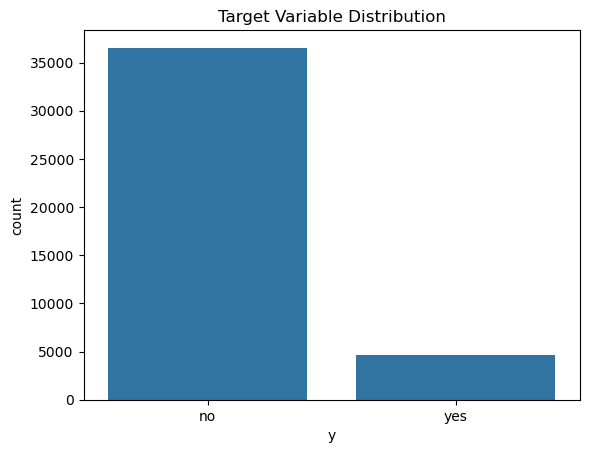

In [11]:
sns.countplot(x='y',data=data)
plt.title("Target Variable Distribution")
plt.show()

# 5. Data Cleaning

In [13]:
data.drop("duration",axis=1, inplace=True)

# 6. Handling Categorical Data

In [15]:
le = LabelEncoder()

for column in data.columns:
    if data[column].dtype== 'object':
        data[column] = le.fit_transform(data[column])

# 7. Split Data into Feature & Target

In [17]:
X = data.drop('y' , axis=1)
y = data['y']

# 8.Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# 9. Model 1: Logistic Regression

In [21]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8993283159342883
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10968
           1       0.68      0.20      0.31      1389

    accuracy                           0.90     12357
   macro avg       0.79      0.59      0.63     12357
weighted avg       0.88      0.90      0.87     12357



# 10. Model 2: Decision Tree

In [22]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

y_pred_data = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_data))

Accuracy: 0.834021202557255


# 11. Model 3: Random Forest

In [23]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8931779558145181
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     10968
           1       0.55      0.30      0.38      1389

    accuracy                           0.89     12357
   macro avg       0.73      0.63      0.66     12357
weighted avg       0.87      0.89      0.88     12357



# 12. Model comparison Report

In [24]:
model_result = pd.DataFrame({
    "Model": ["Logistic Regression", "Decesion Tree", "Random Forest"],
    "Accuracy" : [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_data),
        accuracy_score(y_test, y_pred_rf)
    ]
})

model_result

,Model,Accuracy
0,Logistic Regression,0.899328
1,Decesion Tree,0.834021
2,Random Forest,0.893178


# RandomForest 

In [26]:
rf_model= RandomForestClassifier(n_estimators=200, max_depth=10)

# Train the model

In [28]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200)

# prediction

In [29]:
y_pred_rf = rf_model.predict(X_test)
y_pred_rf

array([0, 0, 0, ..., 0, 0, 0])

# Check Accuracy

In [30]:
# Check Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.9002994254268836


In [31]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95     10968
           1       0.65      0.25      0.36      1389

    accuracy                           0.90     12357
   macro avg       0.78      0.62      0.65     12357
weighted avg       0.88      0.90      0.88     12357



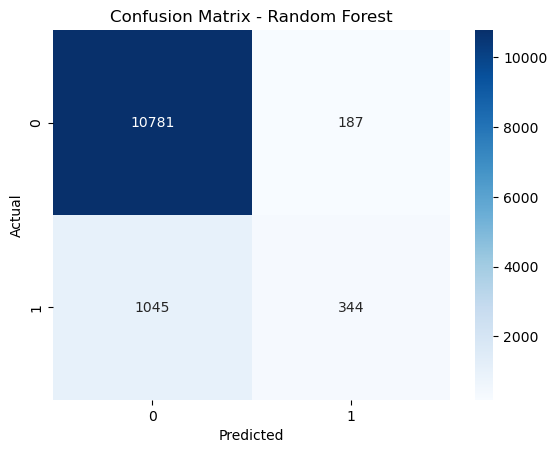

In [32]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d' , cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Feature importance

In [34]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
17,euribor3m,0.189571
18,nr.employed,0.156052
11,pdays,0.104020
16,cons.conf.idx,0.067774
0,age,0.066312
13,poutcome,0.063698
14,emp.var.rate,0.062131
15,cons.price.idx,0.043556
8,month,0.038482
9,day_of_week,0.031153


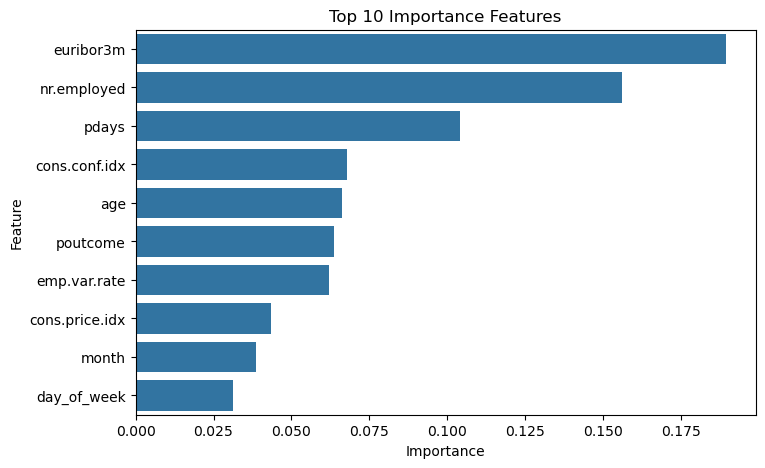

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Importance Features")
plt.show()

In [36]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy" : [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_data),
        accuracy_score(y_test, y_pred_rf)
    ]
})
model_results

,Model,Accuracy
0,Logistic Regression,0.899328
1,Decision Tree,0.834021
2,Random Forest,0.900299


# step 1: Check Class Imbalance

In [38]:
data['y'].value_counts(normalize=True)*100

y
0    88.734583
1    11.265417
Name: proportion, dtype: float64

# step 2: Handle Imbalance 

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# step 3: Evaluate Properly 

In [42]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = rf_model.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.7879616348416416


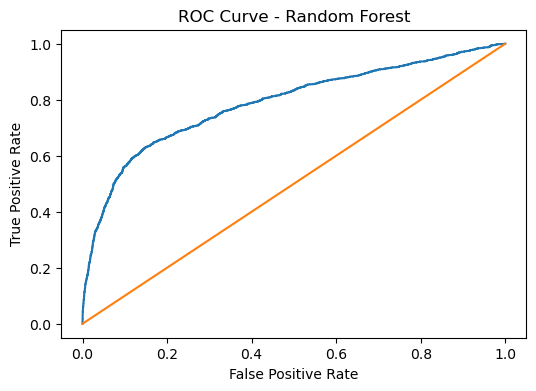

In [43]:
fpr, tpr, thresholds = roc_curve(y_test,y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

# Step 5: Hyperparameter Tuning

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[200,300],
    'max_depth':[10,12,15]
}

grid = GridSearchCV(RandomForestClassifier(class_weight='balanced'),
                    param_grid,
                    cv=3,
                    scoring='roc_auc')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 300}


In [46]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    class_weight='balanced',
    random_state=42
)

In [47]:
rf_model

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=500,
                       random_state=42)

In [48]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score

print("New Accuracy:",accuracy_score(y_test, y_pred_rf))

New Accuracy: 0.8831431577243668


In [50]:
from sklearn.metrics import roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:,1]
roc_score = roc_auc_score(y_test, y_prob)

print("New ROC-AUC Score:", roc_score)

New ROC-AUC Score: 0.7763730433294002


# Step 1: Install

In [51]:
!pip install imbalanced-learn

# Step 2: Apply SMOTE

In [52]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: y
0    25580
1     3251
Name: count, dtype: int64
After SMOTE: y
0    25580
1    25580
Name: count, dtype: int64


In [55]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

y_prob = rf_model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8574087561705915
ROC-AUC: 0.7684436339184769


# XGBoost

In [56]:
!pip install xgboost

# step 1 Train XGBoost

In [57]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=3 
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.8825766771870195
ROC-AUC: 0.7847210078773568


# 3 Threshold Tuning
# step 1 Get Probabilities

In [59]:
y_prob = rf_model.predict_proba(X_test)[:,1]

In [60]:
y_pred_new = (y_prob > 0.3).astype(int)
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.95      0.70      0.81     10968
           1       0.23      0.71      0.35      1389

    accuracy                           0.70     12357
   macro avg       0.59      0.70      0.58     12357
weighted avg       0.87      0.70      0.76     12357



# STEP 1 : SMOTE + Random Forest

# Accuracy: 0.8574087561705915
# ROC-AUC: 0.7684436339184769

# STEP 2 : XGBoost

# Accuracy: 0.8825766771870195
# ROC-AUC: 0.7847210078773568

# STEP 3 : Threshold Tuning

# recall yes=0.71(71%)
 